In [23]:
# Transakcije = skup proizvoda koje je isti korisnik ocenio
# Zadrzavaju se samo korisnici sa >= 2 proizvoda
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [24]:
# ------------------------------------------------------------
# Pomocna funkcija za logovanje vremena
# ------------------------------------------------------------
t0 = time.time()
def log(msg):
    print(f"[{time.time()-t0:6.1f}s] {msg}", flush=True)

In [25]:
# ------------------------------------------------------------
# 1) Ucitavanje podataka
# ------------------------------------------------------------
df = pd.read_csv("Reviews_sample_balanced.csv")

# Provera potrebnih kolona
required_cols = {"UserId", "ProductId"}
if not required_cols.issubset(df.columns):
    raise ValueError(f"Nedostaju kolone: {required_cols - set(df.columns)}")

In [26]:
# ------------------------------------------------------------
# 2) Uklanjanje duplikata
# (isti korisnik – isti proizvod)
# ------------------------------------------------------------
df = df.drop_duplicates(subset=["UserId", "ProductId"])


In [27]:
# ------------------------------------------------------------
# 3) Formiranje transakcija
# (lista ProductId po UserId)
# ------------------------------------------------------------
transactions = (
    df.groupby("UserId")["ProductId"]
      .apply(lambda s: list(pd.unique(s)))
      .tolist()
)

log(f"Ukupno korisnika (transakcija): {len(transactions):,}")

# Analiza duzina transakcija
lens = pd.Series([len(t) for t in transactions])
print("\nStatistika duzine transakcija:")
print(lens.describe())
print("Korisnika sa 1 proizvodom:", (lens == 1).sum())
print("Korisnika sa >=2 proizvoda:", (lens >= 2).sum())

[   3.0s] Ukupno korisnika (transakcija): 25,278

Statistika duzine transakcija:
count    25278.000000
mean         1.184943
std          0.653849
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         22.000000
dtype: float64
Korisnika sa 1 proizvodom: 22265
Korisnika sa >=2 proizvoda: 3013


In [28]:
# ------------------------------------------------------------
# 4) Filtriranje korisnika sa >= 2 proizvoda
# ------------------------------------------------------------
transactions2 = [t for t in transactions if len(t) >= 2]
log(f"Broj transakcija nakon filtriranja: {len(transactions2):,}")

[   3.0s] Broj transakcija nakon filtriranja: 3,013


In [29]:
# ------------------------------------------------------------
# 5) One-hot encoding (TransactionEncoder)
# ------------------------------------------------------------
te = TransactionEncoder()
te_ary = te.fit(transactions2).transform(transactions2)
basket = pd.DataFrame(te_ary, columns=te.columns_)


In [30]:
# ------------------------------------------------------------
# 6) Apriori – cesti skupovi stavki
# (fokus samo na parove proizvoda)
# ------------------------------------------------------------
min_support = 0.002   # ≈ 2 korisnika od 584
log(f"Pokrecem Apriori (min_support={min_support})...")

freq = apriori(
    basket,
    min_support=min_support,
    use_colnames=True,
    max_len=2,
    low_memory=True
)

freq["itemset_len"] = freq["itemsets"].apply(len)
log(f"Ukupno cistih itemset-ova: {len(freq):,}")
log(f"Parovi (len=2): {(freq['itemset_len'] == 2).sum():,}")

[   3.1s] Pokrecem Apriori (min_support=0.002)...
[   3.2s] Ukupno cistih itemset-ova: 207
[   3.2s] Parovi (len=2): 3


In [31]:
# ------------------------------------------------------------
# 7) Association rules
# ------------------------------------------------------------
log("Racunam asocijativna pravila...")
rules = association_rules(freq, metric="lift", min_threshold=1.1)
log(f"Ukupno pravila: {len(rules):,}")

[   3.5s] Racunam asocijativna pravila...
[   3.5s] Ukupno pravila: 6



TOP 10 ASOCIJATIVNIH PRAVILA:
                   antecedents_str                    consequents_str  support  confidence       lift
                     Barilla Penne                  Barilla Spaghetti 0.003319    1.000000 251.083333
                 Barilla Spaghetti                      Barilla Penne 0.003319    0.833333 251.083333
          SF Bay Coffee Fog Chaser         SF Bay Coffee French Roast 0.002323    0.538462 115.884615
        SF Bay Coffee French Roast           SF Bay Coffee Fog Chaser 0.002323    0.500000 115.884615
     SF Bay Coffee Breakfast Blend San Francisco Bay Coffee (Various) 0.002323    0.500000  94.156250
San Francisco Bay Coffee (Various)      SF Bay Coffee Breakfast Blend 0.002323    0.437500  94.156250


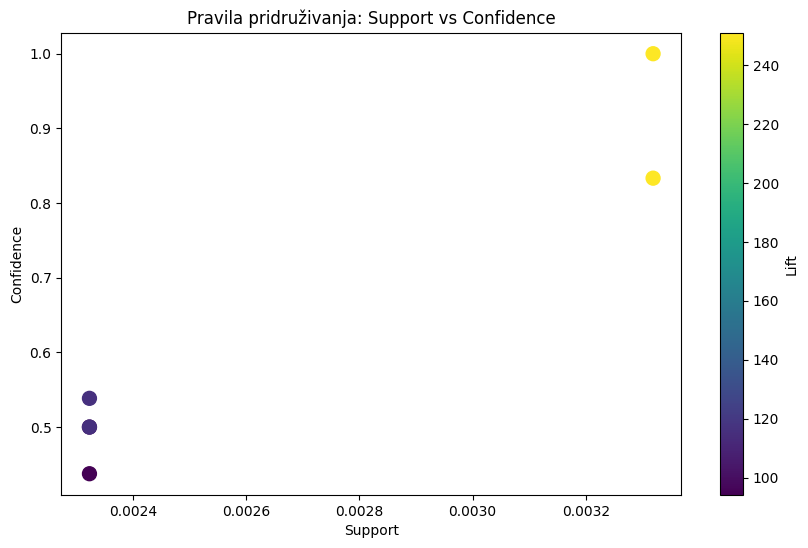

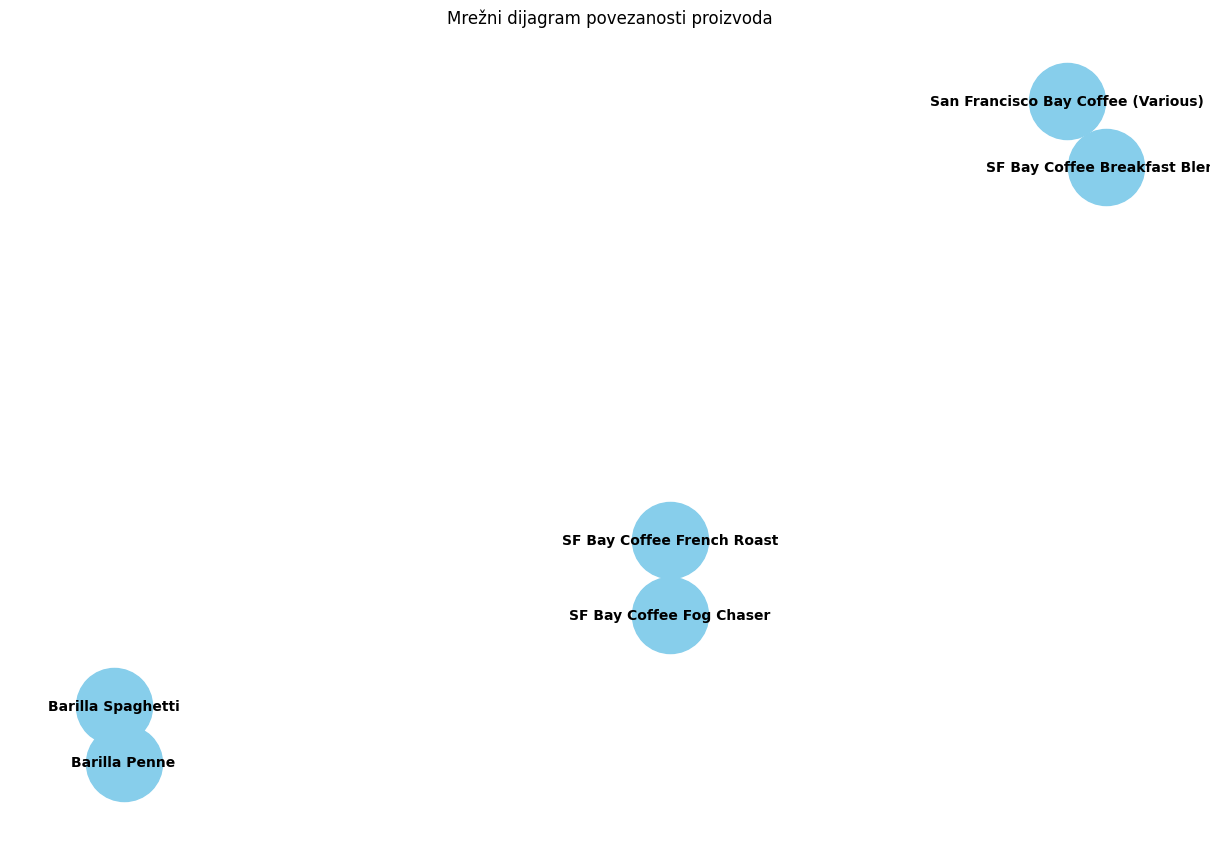

In [36]:
def fs(s):
    return ", ".join(sorted(list(s)))

mapping = {
    "B000KV61FC": "Barilla Spaghetti",
    "B000KV7ZGQ": "Barilla Penne",
    "B005K4Q37A": "SF Bay Coffee Fog Chaser",
    "B005K4Q4LK": "SF Bay Coffee French Roast",
    "B005K4Q1T0": "SF Bay Coffee Breakfast Blend",
    "B0076MLL12": "San Francisco Bay Coffee (Various)"
}

# Funkcija koja menja ID u ime ako ga ima u rečniku
def get_name(id_set):
    item_id = list(id_set)[0]
    return mapping.get(item_id, item_id) # Vrati ime ili ostavi ID ako ga nema u listi



if len(rules) == 0:
    print("\nNEMA PRAVILA za izabrane pragove.")
else:
    # Sortiranje i filtriranje za tabelu
    rules_display = rules.sort_values(["lift", "confidence"], ascending=False).copy()
    
    # Dodajemo formatiranje setova u stringove
    rules_display["antecedents_str"] = rules_display["antecedents"].apply(fs)
    rules_display["consequents_str"] = rules_display["consequents"].apply(fs)

    rules_display["antecedents_str"] = rules["antecedents"].apply(get_name)
    rules_display["consequents_str"] = rules["consequents"].apply(get_name)

    print("\nTOP 10 ASOCIJATIVNIH PRAVILA:")
    print(rules_display[["antecedents_str", "consequents_str", "support", "confidence", "lift"]].head(10).to_string(index=False))

    # --- VIZUELIZACIJA 1 (Scatter plot) ---
    plt.figure(figsize=(10, 6))
    plt.scatter(rules['support'], rules['confidence'], c=rules['lift'], cmap='viridis', s=100)
    plt.colorbar(label='Lift')
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.title('Pravila pridruživanja: Support vs Confidence')
    plt.show()

    # --- VIZUELIZACIJA 2 (Network Graph) ---
    # Ovo vizuelno pokazuje kako su proizvodi povezani
    plt.figure(figsize=(12, 8))
    G = nx.DiGraph()
    
    # top 10 pravila za graf
    for i, row in rules_display.head(10).iterrows():
        G.add_edge(row['antecedents_str'], row['consequents_str'], weight=row['lift'])

    pos = nx.spring_layout(G, k=0.5)
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=3000, 
            edge_color='gray', font_size=10, font_weight='bold', arrows=True)
    plt.title("Mrežni dijagram povezanosti proizvoda")
    plt.show()



In [22]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text',
       'Sentiment'],
      dtype='str')